# Workshop Data Science — Analyse du dataset Gapminder

**Objectif** : Découvrir l'analyse de données et la visualisation avec Python en explorant le dataset Gapminder (pays, population, espérance de vie, PIB par habitant, de 1952 à 2007).

**Outils utilisés** : `pandas`, `matplotlib`, `plotly`

---

## 1. Installation et imports

In [2]:
# Installation (décommentez si nécessaire)
# !pip install -r requirements.txt

import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Pour que les graphiques matplotlib s'affichent dans le notebook
%matplotlib inline

print("Tout est prêt !")

Tout est prêt !


## 2. Charger et découvrir les données

Le dataset Gapminder est intégré à Plotly — pas besoin de télécharger quoi que ce soit !

In [11]:
# Charger le dataset Gapminder
df = px.data.gapminder()

# Afficher les 5 premières lignes
df.head(6)


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4
5,Afghanistan,Asia,1977,38.438,14880372,786.113360,AFG,4


In [10]:
# Informations sur les colonnes
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   str    
 1   continent  1704 non-null   str    
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   str    
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), str(3)
memory usage: 106.6 KB


In [4]:
# Statistiques descriptives
df.describe()

,year,lifeExp,pop,gdpPercap,iso_num
count,1704.00000,1704.000000,1.704000e+03,1704.000000,1704.000000
mean,1979.50000,59.474439,2.960121e+07,7215.327081,425.880282
std,17.26533,12.917107,1.061579e+08,9857.454543,248.305709
min,1952.00000,23.599000,6.001100e+04,241.165876,4.000000
25%,1965.75000,48.198000,2.793664e+06,1202.060309,208.000000
50%,1979.50000,60.712500,7.023596e+06,3531.846989,410.000000
75%,1993.25000,70.845500,1.958522e+07,9325.462346,638.000000
max,2007.00000,82.603000,1.318683e+09,113523.132900,894.000000


In [6]:
# Quels continents et combien de pays ?
"continents :", df['continent'].unique()

('continents :',
 <StringArray>
 ['Asia', 'Europe', 'Africa', 'Americas', 'Oceania']
 Length: 5, dtype: str)

## 3. Visualisations avec Matplotlib

Commençons par des graphiques classiques avec `matplotlib`.

### 3.1 Espérance de vie moyenne par continent (2007)

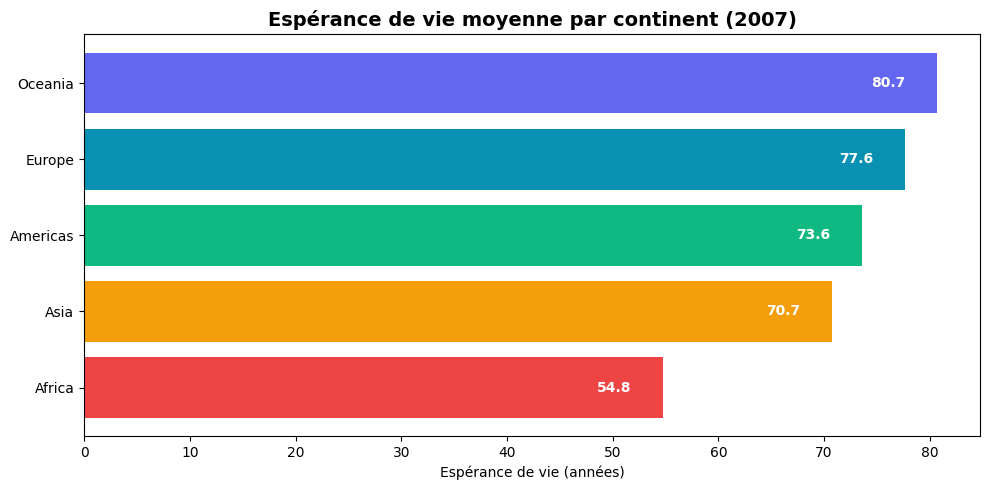

In [12]:
# Filtrer les données de 2007
df_2007 = df[df['year'] == 2007]

# Calculer l'espérance de vie moyenne par continent
life_exp = df_2007.groupby('continent')['lifeExp'].mean().sort_values()

# Créer le graphique
colors = ["#EF4444", "#F59E0B", "#10B981", "#0891B2", "#6366F1"]

plt.figure(figsize=(10, 5))
bars = plt.barh(life_exp.index, life_exp.values, color=colors)
plt.xlabel("Espérance de vie (années)")
plt.title("Espérance de vie moyenne par continent (2007)", fontsize=14, fontweight="bold")

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, life_exp.values):
    plt.text(bar.get_width() - 3, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}", va="center", ha="right", color="white", fontweight="bold")

plt.tight_layout()
plt.show()

### 3.2 Distribution du PIB par habitant (histogramme)

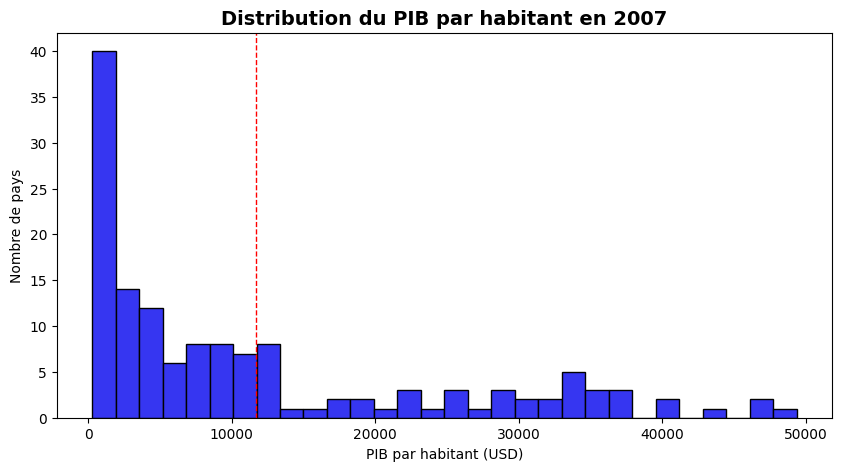

In [18]:
# Distribution du PIB/habitant en 2007
plt.figure(figsize=(10, 5))
plt.hist(df_2007['gdpPercap'], bins=30, color="#3636F1", edgecolor="black")
plt.xlabel("PIB par habitant (USD)")
plt.ylabel("Nombre de pays")
plt.title("Distribution du PIB par habitant en 2007", fontsize=14, fontweight="bold")
plt.axvline(df_2007['gdpPercap'].mean(), color='red', linestyle='dashed', linewidth=1, label=f"Moyenne: {df_2007['gdpPercap'].mean():.2f}")
plt.show()



### 3.3 Évolution de l'espérance de vie de la France

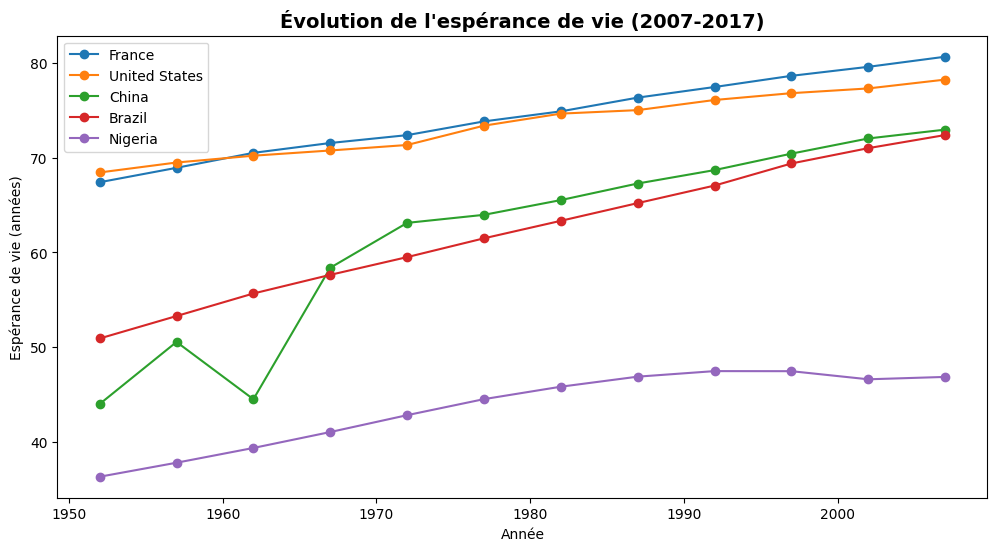

In [15]:
# Comparer la France avec quelques pays
pays = ["France", "United States", "China", "Brazil", "Nigeria"]
df_pays = df[df["country"].isin(pays)]

plt.figure(figsize=(12, 6))
for country in pays:
    df_country = df_pays[df_pays["country"] == country]
    plt.plot(df_country["year"], df_country["lifeExp"], marker="o", label=country)
plt.xlabel("Année")
plt.ylabel("Espérance de vie (années)")
plt.title("Évolution de l'espérance de vie (2007-2017)", fontsize=14, fontweight="bold")
plt.legend()
plt.show()


### 3.4 Scatter plot : PIB vs Espérance de vie

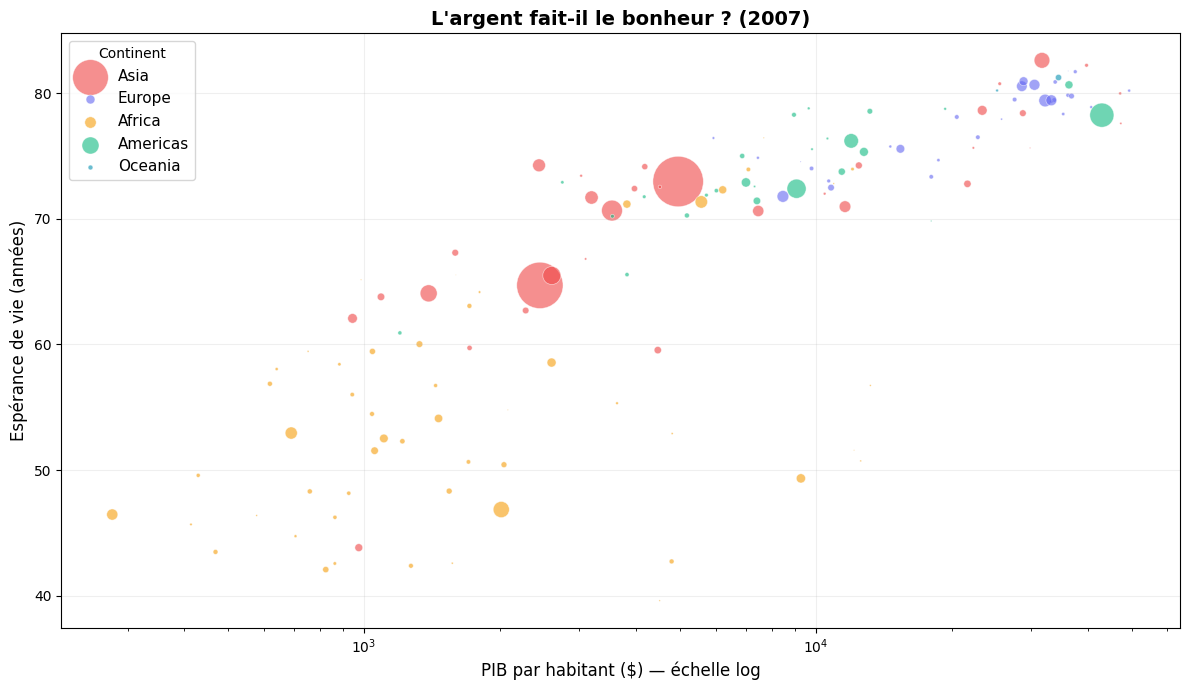

💡 Plus un pays est riche, plus l'espérance de vie est élevée... mais la relation n'est pas linéaire !


In [ ]:
# Scatter plot avec taille = population, couleur = continent
continent_colors = {
    "Asia": "#EF4444",
    "Europe": "#6366F1",
    "Africa": "#F59E0B",
    "Americas": "#10B981",
    "Oceania": "#0891B2",
}
